In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import confusion_matrix,f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay

# ***1. Loading Data***

In [3]:
df = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# ***2. EDA (Exploratory Data Analysis)***

## ***2.1 Understanding Data***

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## ***2.2 Handling Missing Values***

In [8]:
age_imp = SimpleImputer(strategy="median")
df[["Age"]] = age_imp.fit_transform(df[["Age"]])

In [9]:
median_imp = SimpleImputer(strategy="most_frequent")
df[["Cabin"]] = median_imp.fit_transform(df[["Cabin"]])

In [10]:
df[["Embarked"]] = median_imp.fit_transform(df[["Embarked"]])

In [11]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

## ***2.3 Checking Distribution in Dataset***

In [12]:
classes_counts = df["Survived"].value_counts()
classes_counts

Survived
0    549
1    342
Name: count, dtype: int64

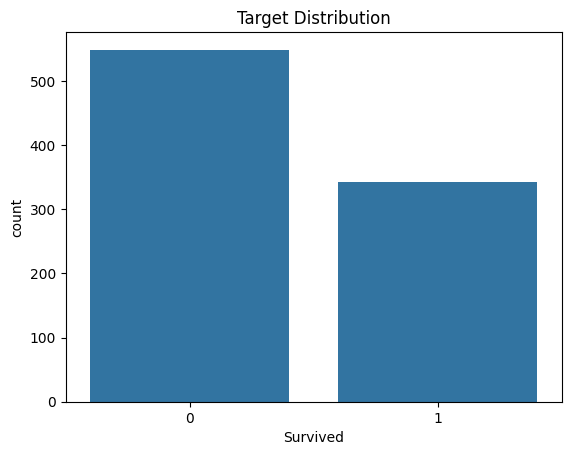

In [13]:
sns.countplot(
    data=df,
     x="Survived"
)
plt.title("Target Distribution")
plt.show()

In [14]:
y = df["Survived"]
df = df.drop(columns=["Survived"])
df["Survived"] = y
df

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,B96 B98,S,0
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,B96 B98,S,1
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,B96 B98,S,0
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,B96 B98,S,0
887,888,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1
888,889,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,B96 B98,S,0
889,890,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,1


## ***2.4 Handling Duplicate Values***

In [15]:
df.duplicated().sum()

np.int64(0)

## ***2.5 Data Visualization***

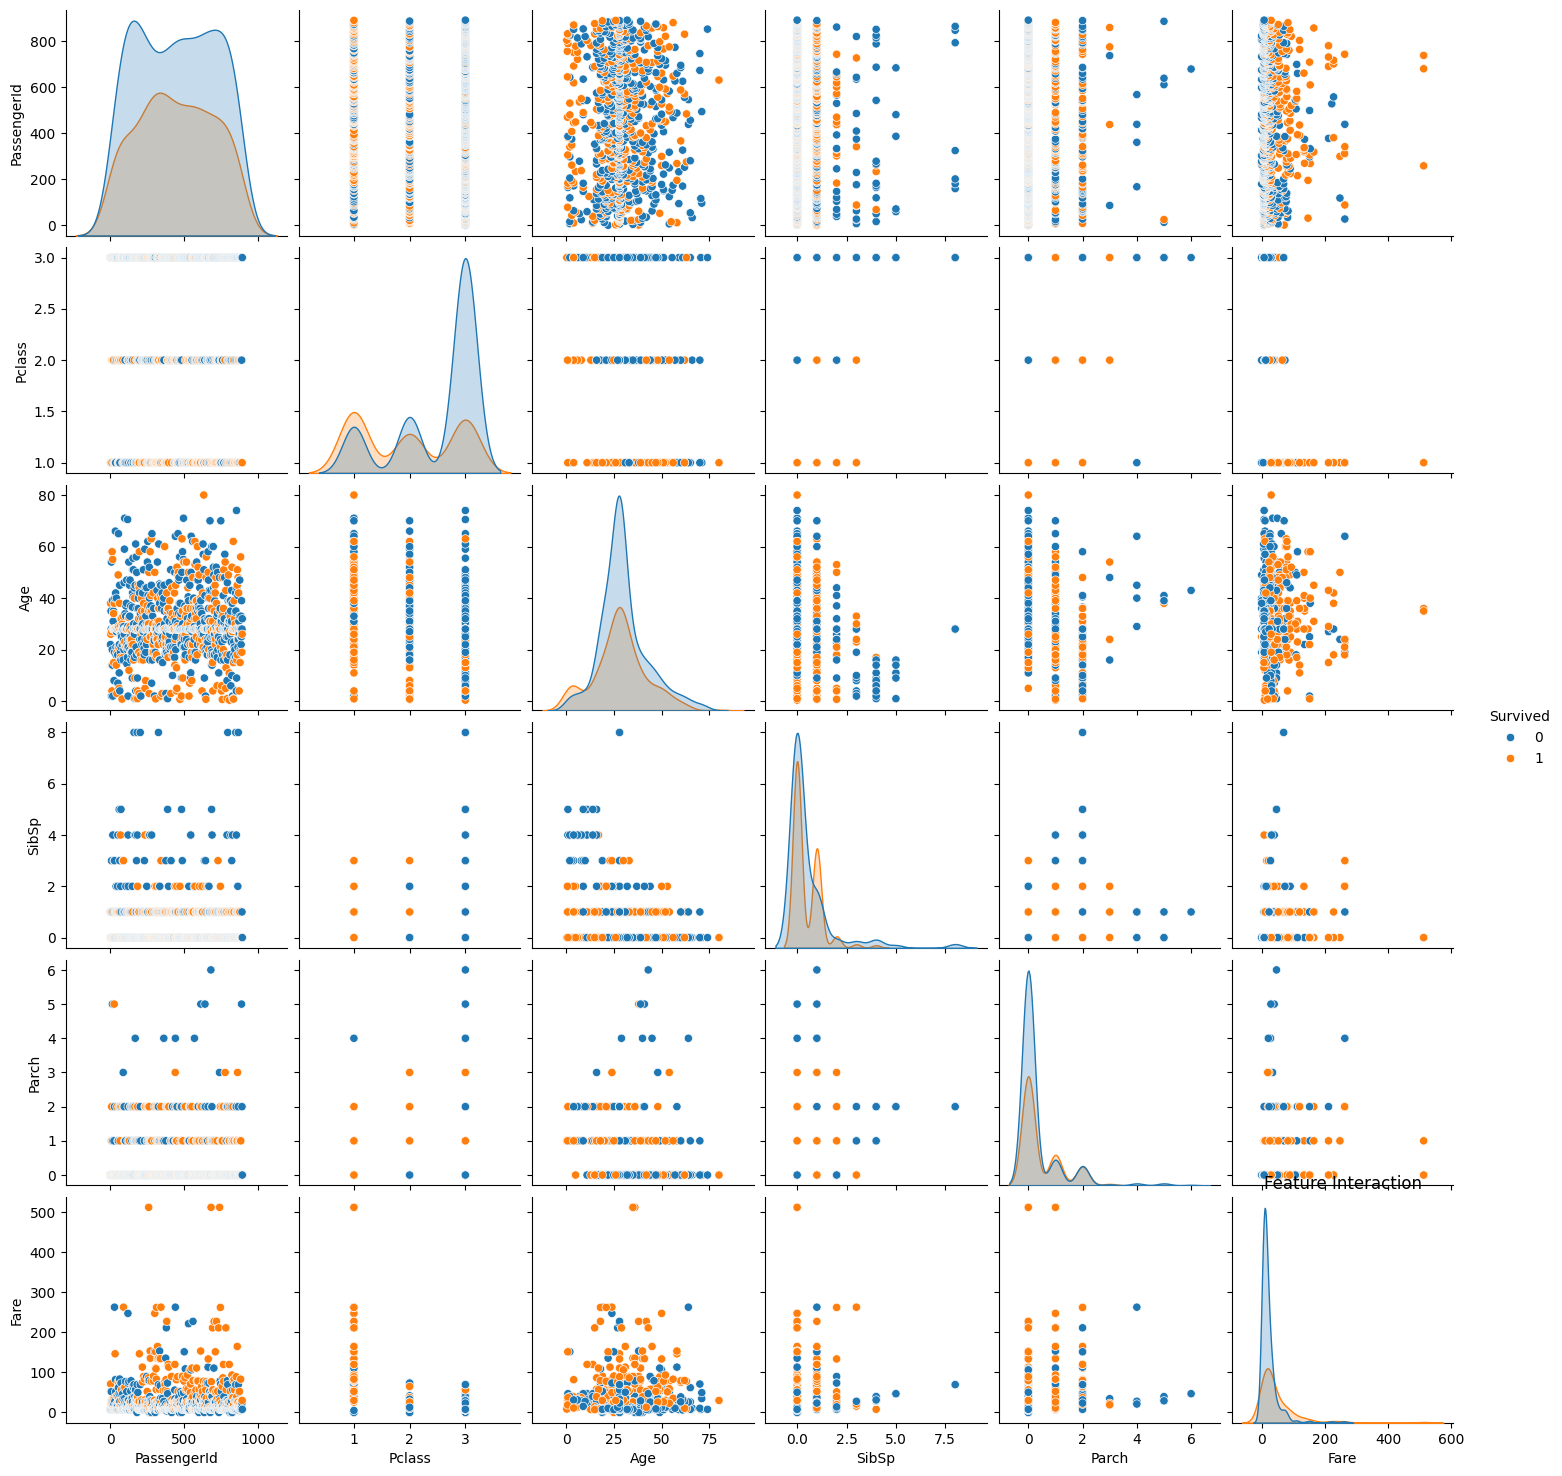

In [16]:
sns.pairplot(df, hue="Survived")
plt.title("Feature Interaction")
plt.show()

In [17]:
df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,B96 B98,S,0
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,B96 B98,S,1
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,B96 B98,S,0


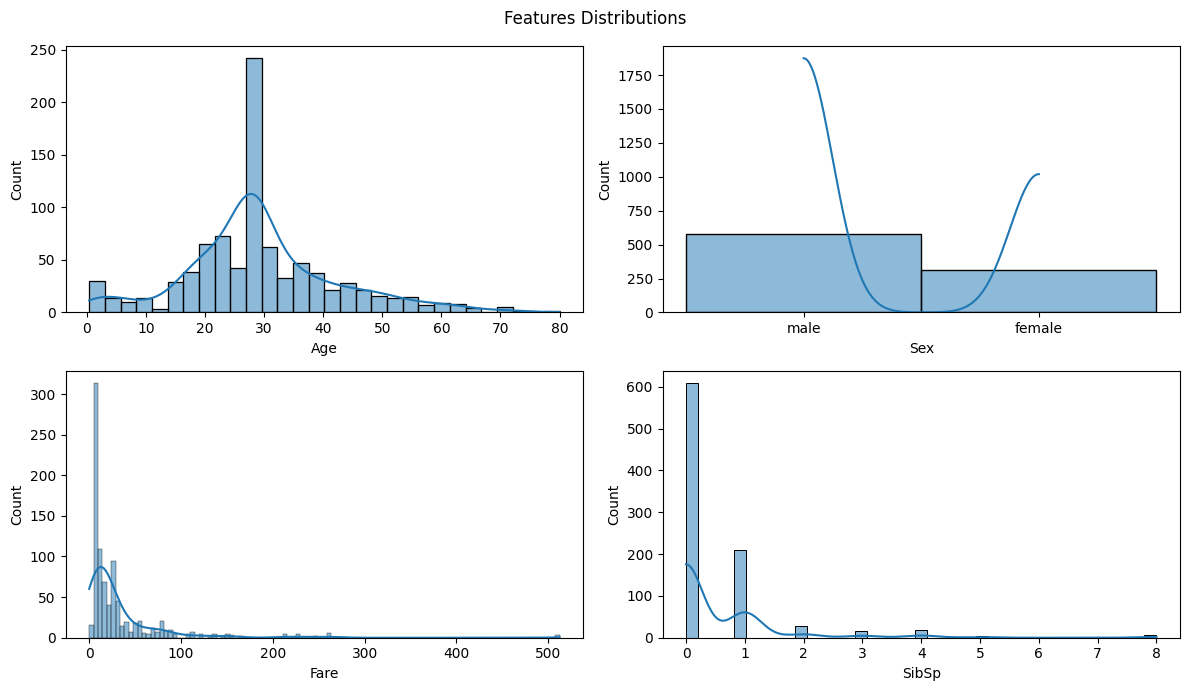

In [18]:
fig, axes = plt.subplots(2,2, figsize=(12,7))
sns.histplot(ax=axes[0,0], data=df,x="Age",kde=True)
sns.histplot(ax=axes[0,1], data=df,x="Sex",kde=True)
sns.histplot(ax=axes[1,0], data=df,x="Fare",kde=True)
sns.histplot(ax=axes[1,1], data=df,x="SibSp",kde=True)
fig.suptitle("Features Distributions")
plt.tight_layout()
plt.show()

# ***3. Feature Engineering***

## ***3.1 Feature Selection***

In [19]:
cleaned_df= df.drop(columns=["PassengerId","Name","Ticket","Cabin"])

In [20]:
cleaned_df

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,3,male,22.0,1,0,7.2500,S,0
1,1,female,38.0,1,0,71.2833,C,1
2,3,female,26.0,0,0,7.9250,S,1
3,1,female,35.0,1,0,53.1000,S,1
4,3,male,35.0,0,0,8.0500,S,0
...,...,...,...,...,...,...,...,...
886,2,male,27.0,0,0,13.0000,S,0
887,1,female,19.0,0,0,30.0000,S,1
888,3,female,28.0,1,2,23.4500,S,0
889,1,male,26.0,0,0,30.0000,C,1


## ***3.2 Feature Encoding***

In [21]:
cleaned_df["Embarked"].nunique()

3

In [22]:
cleaned_df["Sex"] = cleaned_df["Sex"].map({"male":1, "female":0})
cleaned_df["Embarked"] = cleaned_df["Embarked"].map({"S":0, "C":1,"Q":2})
cleaned_df

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,3,1,22.0,1,0,7.2500,0,0
1,1,0,38.0,1,0,71.2833,1,1
2,3,0,26.0,0,0,7.9250,0,1
3,1,0,35.0,1,0,53.1000,0,1
4,3,1,35.0,0,0,8.0500,0,0
...,...,...,...,...,...,...,...,...
886,2,1,27.0,0,0,13.0000,0,0
887,1,0,19.0,0,0,30.0000,0,1
888,3,0,28.0,1,2,23.4500,0,0
889,1,1,26.0,0,0,30.0000,1,1


## ***3.3 Correlation Matrix***

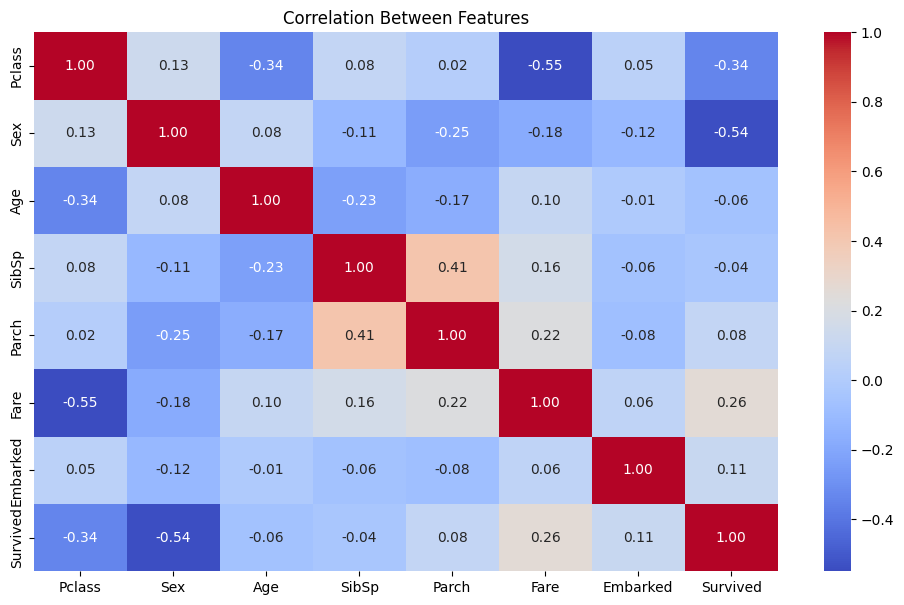

In [23]:
num_cols = cleaned_df.select_dtypes(include="number")
corr_matrix = num_cols.corr()
corr_matrix["Survived"].sort_values()
plt.figure(figsize=(12,7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Between Features")
plt.show()

### Insigts-
1. Sex and Target Value has negative feature (Mostlty Males dies)
2. Parch and SibSp has +ve correlation
3. Age and Pclass has -ve correlation
4. Fare and Survived also has small +ve correlation

## ***3.3 Feature Scaling***

In [24]:
scaler = StandardScaler()

In [25]:
X = cleaned_df.drop(columns=["Survived"])
y = cleaned_df["Survived"]

In [26]:
X.shape

(891, 7)

In [27]:
X_train, X_val,y_train, y_val = train_test_split(
    X,y, test_size=0.3,random_state=42
)

In [28]:
X_train.shape

(623, 7)

In [29]:
X_val.shape

(268, 7)

In [30]:
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [31]:
X_train_scaled

array([[-1.63788124,  0.72077194, -1.91971935, ...,  1.99885349,
         0.98099823, -0.55489425],
       [ 0.80326712,  0.72077194, -0.0772525 , ..., -0.47932706,
        -0.46963364, -0.55489425],
       [ 0.80326712, -1.38740139, -2.15002771, ...,  0.75976322,
        -0.40613632, -0.55489425],
       ...,
       [ 0.80326712,  0.72077194,  0.92075038, ..., -0.47932706,
        -0.34778742, -0.55489425],
       [-1.63788124, -1.38740139, -1.15202483, ...,  1.99885349,
         1.72907416, -0.55489425],
       [-1.63788124,  0.72077194, -0.61463866, ...,  0.75976322,
         0.8913508 , -0.55489425]])

# ***4. Modeling***

## ***4.1 Baseline Model (Logistic Regression)***

### ***4.1.1 Model Training***

In [32]:
log_clf = LogisticRegression()
model = log_clf.fit(X_train_scaled, y_train)

In [33]:
y_train_pred = model.predict(X_train_scaled)
y_val_pred = model.predict(X_val_scaled)

### ***4.1.2 Model Evaluation***

In [34]:
print("Trainig Evaluation : ")
print("Accuracy scaore : ",accuracy_score(y_train,y_train_pred))
print("F1 scaore : ",f1_score(y_train,y_train_pred))
print("Confusion Matrix : ")
print(confusion_matrix(y_train,y_train_pred))
print("Classification Report : ") 
print(classification_report(y_train,y_train_pred))

Trainig Evaluation : 
Accuracy scaore :  0.7961476725521669
F1 scaore :  0.7107061503416856
Confusion Matrix : 
[[340  52]
 [ 75 156]]
Classification Report : 
              precision    recall  f1-score   support

           0       0.82      0.87      0.84       392
           1       0.75      0.68      0.71       231

    accuracy                           0.80       623
   macro avg       0.78      0.77      0.78       623
weighted avg       0.79      0.80      0.79       623



In [35]:
print("Validation Evaluation : ")
print("Accuracy scaore : ",accuracy_score(y_val,y_val_pred))
print("Recall scaore : ",recall_score(y_val,y_val_pred))
print("F1 scaore : ",f1_score(y_val,y_val_pred))
print("Confusion Matrix : ")
print(confusion_matrix(y_val,y_val_pred))
print("Classification Report : ")
print(classification_report(y_val,y_val_pred))

Validation Evaluation : 
Accuracy scaore :  0.8059701492537313
Recall scaore :  0.7207207207207207
F1 scaore :  0.7547169811320755
Confusion Matrix : 
[[136  21]
 [ 31  80]]
Classification Report : 
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       157
           1       0.79      0.72      0.75       111

    accuracy                           0.81       268
   macro avg       0.80      0.79      0.80       268
weighted avg       0.81      0.81      0.80       268



### ***4.1.3 Logistic Regression with Regularization***

In [36]:
l1_model = LogisticRegression(penalty="l1", solver="liblinear", C=0.1, random_state=42)
l1_model.fit(X_train_scaled,y_train)

LogisticRegression(C=0.1, penalty='l1', random_state=42, solver='liblinear')

In [37]:
y_l1_train_pred = l1_model.predict(X_train_scaled)
y_l1_val_pred = l1_model.predict(X_val_scaled)

In [38]:
print("Trainig Evaluation : ")
print("Accuracy scaore : ",accuracy_score(y_train,y_l1_train_pred))
print("F1 scaore : ",f1_score(y_train,y_l1_train_pred))
print("Confusion Matrix : ")
print(confusion_matrix(y_train,y_l1_train_pred))
print("Classification Report : ") 
print(classification_report(y_train,y_l1_train_pred))

Trainig Evaluation : 
Accuracy scaore :  0.7945425361155698
F1 scaore :  0.7117117117117117
Confusion Matrix : 
[[337  55]
 [ 73 158]]
Classification Report : 
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       392
           1       0.74      0.68      0.71       231

    accuracy                           0.79       623
   macro avg       0.78      0.77      0.78       623
weighted avg       0.79      0.79      0.79       623



In [39]:
print("Validation Evaluation : ")
print("Accuracy scaore : ",accuracy_score(y_val,y_l1_val_pred))
print("Recall scaore : ",recall_score(y_val,y_l1_val_pred))
print("F1 scaore : ",f1_score(y_val,y_l1_val_pred))
print("Confusion Matrix : ")
print(confusion_matrix(y_val,y_l1_val_pred))
print("Classification Report : ") 
print(classification_report(y_val,y_l1_val_pred))

Validation Evaluation : 
Accuracy scaore :  0.7910447761194029
Recall scaore :  0.7207207207207207
F1 scaore :  0.7407407407407407
Confusion Matrix : 
[[132  25]
 [ 31  80]]
Classification Report : 
              precision    recall  f1-score   support

           0       0.81      0.84      0.82       157
           1       0.76      0.72      0.74       111

    accuracy                           0.79       268
   macro avg       0.79      0.78      0.78       268
weighted avg       0.79      0.79      0.79       268



## ***4.2 KNN Classifier***

In [40]:
knn = KNeighborsClassifier()

In [41]:
model_knn = knn.fit(X_train_scaled, y_train)

In [42]:
y_val_knn_pred = model_knn.predict(X_val_scaled)

In [43]:
print("Validation Evaluation : ")
print("Accuracy scaore : ",accuracy_score(y_val,y_val_knn_pred))
print("Recall scaore : ",recall_score(y_val,y_val_knn_pred))
print("F1 scaore : ",f1_score(y_val,y_val_knn_pred))
print("Confusion Matrix : ")
print(confusion_matrix(y_val,y_val_knn_pred))
print("Classification Report : ") 
print(classification_report(y_val,y_val_knn_pred))

Validation Evaluation : 
Accuracy scaore :  0.8059701492537313
Recall scaore :  0.6756756756756757
F1 scaore :  0.7425742574257426
Confusion Matrix : 
[[141  16]
 [ 36  75]]
Classification Report : 
              precision    recall  f1-score   support

           0       0.80      0.90      0.84       157
           1       0.82      0.68      0.74       111

    accuracy                           0.81       268
   macro avg       0.81      0.79      0.79       268
weighted avg       0.81      0.81      0.80       268



### ***4.2.1 Tuning***

In [44]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

param_grid = {"knn__n_neighbors":[3,5,7,9]}
classifier_cv = GridSearchCV(
    pipeline, param_grid, cv=5, scoring="recall"
)

In [45]:
classifier_cv.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('knn', KNeighborsClassifier())]),
             param_grid={'knn__n_neighbors': [3, 5, 7, 9]}, scoring='recall')

In [46]:
y_knn_cv_pred = classifier_cv.predict(X_val)

In [47]:

print("Validation Evaluation : ")
print("Accuracy scaore : ",accuracy_score(y_val,y_knn_cv_pred))
print("Recall scaore : ",recall_score(y_val,y_knn_cv_pred))
print("F1 scaore : ",f1_score(y_val,y_knn_cv_pred))
print("Confusion Matrix : ")
print(confusion_matrix(y_val,y_knn_cv_pred))
print("Classification Report : ") 
print(classification_report(y_val,y_knn_cv_pred))

Validation Evaluation : 
Accuracy scaore :  0.7910447761194029
Recall scaore :  0.6846846846846847
F1 scaore :  0.7307692307692307
Confusion Matrix : 
[[136  21]
 [ 35  76]]
Classification Report : 
              precision    recall  f1-score   support

           0       0.80      0.87      0.83       157
           1       0.78      0.68      0.73       111

    accuracy                           0.79       268
   macro avg       0.79      0.78      0.78       268
weighted avg       0.79      0.79      0.79       268



## ***4.3 SVClassifier***

In [48]:
svc = SVC()
model_svc = svc.fit(X_train_scaled, y_train)

In [49]:
y_svc_pred = model_svc.predict(X_val_scaled)

In [50]:
print("Validation Evaluation : ")
print("Accuracy scaore : ",accuracy_score(y_val,y_svc_pred))
print("Recall scaore : ",recall_score(y_val,y_svc_pred))
print("F1 scaore : ",f1_score(y_val,y_svc_pred))
print("Confusion Matrix : ")
print(confusion_matrix(y_val,y_svc_pred))
print("Classification Report : ") 
print(classification_report(y_val,y_svc_pred))

Validation Evaluation : 
Accuracy scaore :  0.8171641791044776
Recall scaore :  0.6576576576576577
F1 scaore :  0.7487179487179487
Confusion Matrix : 
[[146  11]
 [ 38  73]]
Classification Report : 
              precision    recall  f1-score   support

           0       0.79      0.93      0.86       157
           1       0.87      0.66      0.75       111

    accuracy                           0.82       268
   macro avg       0.83      0.79      0.80       268
weighted avg       0.82      0.82      0.81       268



### ***4.3.1 Tuning***

In [51]:
C_vals = [0.5,1,1.5,2,2.5,3,3.5,4,5]
for c_val in C_vals:
    svc = SVC(C=c_val)
    svc.fit(X_train_scaled,y_train)
    y_svct_pred = svc.predict(X_val_scaled)
    print(f"C={c_val}, Recall = ", recall_score(y_val,y_svct_pred), "Accuracy = ", accuracy_score(y_val, y_svct_pred))

C=0.5, Recall =  0.6666666666666666 Accuracy =  0.8208955223880597
C=1, Recall =  0.6576576576576577 Accuracy =  0.8171641791044776
C=1.5, Recall =  0.6576576576576577 Accuracy =  0.8171641791044776
C=2, Recall =  0.6576576576576577 Accuracy =  0.8171641791044776
C=2.5, Recall =  0.6576576576576577 Accuracy =  0.8171641791044776
C=3, Recall =  0.6576576576576577 Accuracy =  0.8171641791044776
C=3.5, Recall =  0.6576576576576577 Accuracy =  0.8171641791044776
C=4, Recall =  0.6486486486486487 Accuracy =  0.8097014925373134
C=5, Recall =  0.6396396396396397 Accuracy =  0.8097014925373134


In [52]:
svc_final = SVC(C=0.5)
model_svc_final = svc_final.fit(X_train_scaled, y_train)

In [53]:
y_svc_final_pred = model_svc_final.predict(X_val_scaled)

In [54]:
print("Validation Evaluation : ")
print("Accuracy scaore : ",accuracy_score(y_val,y_svc_final_pred))
print("Recall scaore : ",recall_score(y_val,y_svc_final_pred))
print("F1 scaore : ",f1_score(y_val,y_svc_final_pred))
print("Confusion Matrix : ")
print(confusion_matrix(y_val,y_svc_final_pred))
print("Classification Report : ") 
print(classification_report(y_val,y_svc_final_pred))

Validation Evaluation : 
Accuracy scaore :  0.8208955223880597
Recall scaore :  0.6666666666666666
F1 scaore :  0.7551020408163265
Confusion Matrix : 
[[146  11]
 [ 37  74]]
Classification Report : 
              precision    recall  f1-score   support

           0       0.80      0.93      0.86       157
           1       0.87      0.67      0.76       111

    accuracy                           0.82       268
   macro avg       0.83      0.80      0.81       268
weighted avg       0.83      0.82      0.82       268



## ***4.4 Random Forest***

In [55]:
rfc = RandomForestClassifier()
model_rfc = rfc.fit(X_train_scaled, y_train)

In [56]:
y_rfc_pred = model_rfc.predict(X_val_scaled)

In [57]:
print("Validation Evaluation : ")
print("Accuracy scaore : ",accuracy_score(y_val,y_rfc_pred))
print("Recall scaore : ",recall_score(y_val,y_rfc_pred))
print("F1 scaore : ",f1_score(y_val,y_rfc_pred))
print("Confusion Matrix : ")
print(confusion_matrix(y_val,y_rfc_pred))
print("Classification Report : ") 
print(classification_report(y_val,y_rfc_pred))

Validation Evaluation : 
Accuracy scaore :  0.7873134328358209
Recall scaore :  0.7117117117117117
F1 scaore :  0.7348837209302326
Confusion Matrix : 
[[132  25]
 [ 32  79]]
Classification Report : 
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       157
           1       0.76      0.71      0.73       111

    accuracy                           0.79       268
   macro avg       0.78      0.78      0.78       268
weighted avg       0.79      0.79      0.79       268



### ***4.4.1 Tuning***

In [58]:
n_estimators = [101,201,301,401,501,601]
best_estimator=0
max_acc=0
for estimator in n_estimators:
    rfc = RandomForestClassifier(n_estimators=estimator,random_state=42)
    rfc.fit(X_train_scaled,y_train)
    y_rfct_pred = rfc.predict(X_val_scaled)
    acc = accuracy_score(y_val, y_rfct_pred)
    print(f"For estimator={estimator}, Accuracy_score={acc}")
    if max_acc < acc:
        max_acc = acc
        best_estimator = estimator

print(f"Best No. of Estimators={best_estimator} having Accuracy score={max_acc}")

For estimator=101, Accuracy_score=0.8022388059701493
For estimator=201, Accuracy_score=0.7835820895522388
For estimator=301, Accuracy_score=0.7835820895522388
For estimator=401, Accuracy_score=0.7798507462686567
For estimator=501, Accuracy_score=0.7798507462686567
For estimator=601, Accuracy_score=0.7761194029850746
Best No. of Estimators=101 having Accuracy score=0.8022388059701493


In [59]:
max_depths = [2,3,4,5,6,7,8,9,10,12,14,15]
best_depth=0
max_acc=0
for depth in max_depths:
    rfc = RandomForestClassifier(max_depth=depth,random_state=42)
    rfc.fit(X_train_scaled,y_train)
    y_rfct_pred = rfc.predict(X_val_scaled)
    acc = accuracy_score(y_val, y_rfct_pred)
    print(f"For Depth={depth}, Accuracy_score={acc}")
    if max_acc < acc:
        max_acc = acc
        best_depth = depth

print(f"Best Max_depth ={best_depth} having Accuracy score={max_acc}")

For Depth=2, Accuracy_score=0.7873134328358209
For Depth=3, Accuracy_score=0.8171641791044776
For Depth=4, Accuracy_score=0.8208955223880597
For Depth=5, Accuracy_score=0.8171641791044776
For Depth=6, Accuracy_score=0.8097014925373134
For Depth=7, Accuracy_score=0.8208955223880597
For Depth=8, Accuracy_score=0.8097014925373134
For Depth=9, Accuracy_score=0.8022388059701493
For Depth=10, Accuracy_score=0.8097014925373134
For Depth=12, Accuracy_score=0.7985074626865671
For Depth=14, Accuracy_score=0.7985074626865671
For Depth=15, Accuracy_score=0.8022388059701493
Best Max_depth =4 having Accuracy score=0.8208955223880597


In [60]:
min_sample_splits = [2, 4, 6, 8, 10, 20, 50, 100,120,130,150]
best_split=0
max_acc=0
for split in min_sample_splits:
    rfc = RandomForestClassifier(min_samples_split=split,random_state=42)
    rfc.fit(X_train_scaled,y_train)
    y_rfct_pred = rfc.predict(X_val_scaled)
    acc = accuracy_score(y_val, y_rfct_pred)
    print(f"For Split={split}, Accuracy_score={acc}")
    if max_acc < acc:
        max_acc = acc
        best_split = split

print(f"Best Min Samples Split ={best_split} having Accuracy score={max_acc}")

For Split=2, Accuracy_score=0.8022388059701493
For Split=4, Accuracy_score=0.8059701492537313
For Split=6, Accuracy_score=0.8022388059701493
For Split=8, Accuracy_score=0.8134328358208955
For Split=10, Accuracy_score=0.7985074626865671
For Split=20, Accuracy_score=0.8059701492537313
For Split=50, Accuracy_score=0.8246268656716418
For Split=100, Accuracy_score=0.8134328358208955
For Split=120, Accuracy_score=0.8134328358208955
For Split=130, Accuracy_score=0.8134328358208955
For Split=150, Accuracy_score=0.7985074626865671
Best Min Samples Split =50 having Accuracy score=0.8246268656716418


In [61]:
min_sample_leaf = [1,2,3,4,5,10,15,20,25,30,35,40,45,50]
best_leaf=0
max_acc=0
for leaf in min_sample_leaf:
    rfc = RandomForestClassifier(min_samples_leaf=leaf,random_state=42)
    rfc.fit(X_train_scaled,y_train)
    y_rfct_pred = rfc.predict(X_val_scaled)
    acc = accuracy_score(y_val, y_rfct_pred)
    print(f"For Leaf={leaf}, Accuracy_score={acc}")
    if max_acc < acc:
        max_acc = acc
        best_leaf = leaf

print(f"Best Min Samples leaf ={best_leaf} having Accuracy score={max_acc}")

For Leaf=1, Accuracy_score=0.8022388059701493
For Leaf=2, Accuracy_score=0.8171641791044776
For Leaf=3, Accuracy_score=0.8134328358208955
For Leaf=4, Accuracy_score=0.8097014925373134
For Leaf=5, Accuracy_score=0.8171641791044776
For Leaf=10, Accuracy_score=0.8208955223880597
For Leaf=15, Accuracy_score=0.8134328358208955
For Leaf=20, Accuracy_score=0.7985074626865671
For Leaf=25, Accuracy_score=0.8097014925373134
For Leaf=30, Accuracy_score=0.8059701492537313
For Leaf=35, Accuracy_score=0.7723880597014925
For Leaf=40, Accuracy_score=0.753731343283582
For Leaf=45, Accuracy_score=0.7686567164179104
For Leaf=50, Accuracy_score=0.7686567164179104
Best Min Samples leaf =10 having Accuracy score=0.8208955223880597


In [62]:
max_leaf_nodes = [5,10,20,30,40,50,55,60,65,70,75]
best_leaf_node=0
max_acc=0
for leaf in max_leaf_nodes:
    rfc = RandomForestClassifier(max_leaf_nodes=leaf,random_state=42)
    rfc.fit(X_train_scaled,y_train)
    y_rfct_pred = rfc.predict(X_val_scaled)
    acc = accuracy_score(y_val, y_rfct_pred)
    print(f"For Leaf={leaf}, Accuracy_score={acc}")
    if max_acc < acc:
        max_acc = acc
        best_leaf_node = leaf

print(f"Best Max leaf Node ={best_leaf_node} having Accuracy score={max_acc}")

For Leaf=5, Accuracy_score=0.7947761194029851
For Leaf=10, Accuracy_score=0.8208955223880597
For Leaf=20, Accuracy_score=0.8022388059701493
For Leaf=30, Accuracy_score=0.8059701492537313
For Leaf=40, Accuracy_score=0.8208955223880597
For Leaf=50, Accuracy_score=0.8208955223880597
For Leaf=55, Accuracy_score=0.8171641791044776
For Leaf=60, Accuracy_score=0.8134328358208955
For Leaf=65, Accuracy_score=0.7985074626865671
For Leaf=70, Accuracy_score=0.7947761194029851
For Leaf=75, Accuracy_score=0.7947761194029851
Best Max leaf Node =10 having Accuracy score=0.8208955223880597


### ***4.4.2 Final Model Training***

In [63]:
rfc_final = RandomForestClassifier(
    n_estimators = best_estimator,
    min_samples_split = best_split,
    max_depth = best_depth,
    min_samples_leaf= best_leaf,
    max_leaf_nodes = best_leaf_node,
    random_state=42
)
final_model = rfc_final.fit(X_train_scaled, y_train)

In [64]:
y_rfc_final_pred = final_model.predict(X_val_scaled)

In [65]:
print("Validation Evaluation : ")
print("Accuracy scaore : ",accuracy_score(y_val,y_rfc_final_pred))
print("Recall scaore : ",recall_score(y_val,y_rfc_final_pred))
print("F1 scaore : ",f1_score(y_val,y_rfc_final_pred))
print("Confusion Matrix : ")
print(confusion_matrix(y_val,y_rfc_final_pred))
print("Classification Report : ") 
print(classification_report(y_val,y_rfc_final_pred))

Validation Evaluation : 
Accuracy scaore :  0.8171641791044776
Recall scaore :  0.6666666666666666
F1 scaore :  0.751269035532995
Confusion Matrix : 
[[145  12]
 [ 37  74]]
Classification Report : 
              precision    recall  f1-score   support

           0       0.80      0.92      0.86       157
           1       0.86      0.67      0.75       111

    accuracy                           0.82       268
   macro avg       0.83      0.80      0.80       268
weighted avg       0.82      0.82      0.81       268



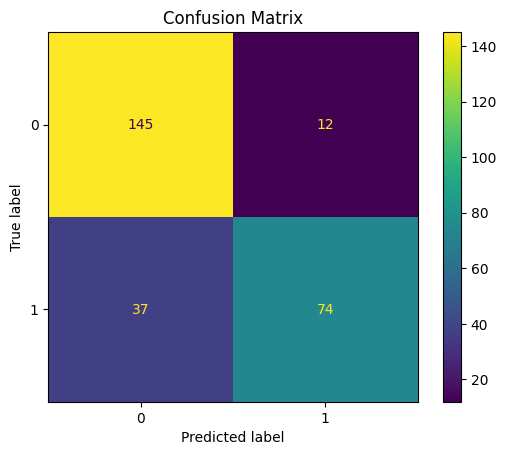

In [66]:
ConfusionMatrixDisplay.from_estimator(
    final_model, X_val_scaled,y_val
)
plt.title("Confusion Matrix")
plt.show()

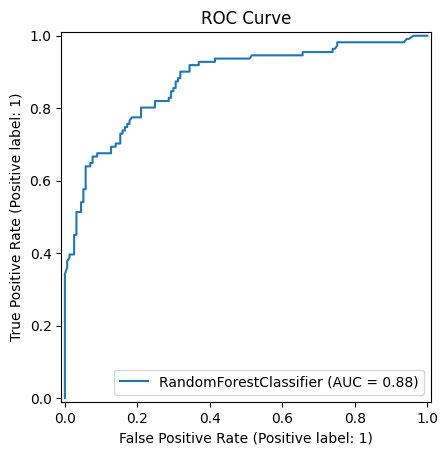

In [67]:
RocCurveDisplay.from_estimator(
    final_model, X_val_scaled, y_val
)
plt.title("ROC Curve")
plt.show()

# 5. Summary & Conclusion

## Model Comparison

| Model | Validation Accuracy | Recall | F1 Score |
|---|---|---|---|
| Logistic Regression (default) | 80.60% | 72.07% | 75.47% |
| Logistic Regression (L1, C=0.1) | 79.10% | 72.07% | 74.07% |
| KNN (default) | 80.60% | 67.57% | 74.26% |
| KNN (tuned, GridSearchCV) | 79.10% | 68.47% | 73.08% |
| SVC (default) | 81.72% | 65.77% | 74.87% |
| **SVC (tuned, C=0.5)** | **82.09%** | **66.67%** | **75.51%** |
| Random Forest (default) | 79.10% | 72.07% | 74.07% |
| Random Forest (tuned) | 81.72% | 66.67% | 75.13% |

## Winner: SVC with C=0.5 

**Best model:** Support Vector Classifier with `C=0.5`  
**Validation Accuracy:** 82.09%  
**F1 Score:** 75.51%

### Why SVC won:
- SVC finds the **optimal decision boundary** (maximum margin hyperplane) between survivors and non-survivors, which works well on this small, structured dataset.
- A slightly **lower C=0.5** (vs default C=1) means more regularization — it tolerates a few misclassifications to get a wider margin, which reduced overfitting on unseen data.
- Unlike Random Forest, SVC is not prone to overfitting on small datasets with few features.
- Logistic Regression came close (80.6%) but the linear boundary is less flexible than SVC's kernel.

### Key Findings from EDA:
- **Sex** was the strongest predictor — females had a much higher survival rate ("women and children first").
- **Pclass** (passenger class) strongly correlated with survival — 1st class passengers survived more.
- **Fare** had a small positive correlation with survival.
- **Age** had a weak negative correlation — younger passengers slightly more likely to survive.



# ***6. Test Set Inference & Submission***

In [68]:
test_df = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")
print("Test set shape:", test_df.shape)
test_df.head()

Test set shape: (418, 11)


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


# ***6.1 Apply the same preprocessing as training data***

In [69]:
passenger_ids = test_df["PassengerId"]

# Impute missing values 
test_df[["Age"]]      = age_imp.transform(test_df[["Age"]])
test_df[["Embarked"]] = median_imp.transform(test_df[["Embarked"]])

# Fare — test set has 1 missing value
fare_imp = SimpleImputer(strategy="median")
test_df[["Fare"]] = fare_imp.fit_transform(test_df[["Fare"]])

# Encode categorical columns 
test_df["Sex"]      = test_df["Sex"].map({"male": 1, "female": 0})
test_df["Embarked"] = test_df["Embarked"].map({"S": 0, "C": 1, "Q": 2})

# Explicitly select ONLY the 7 columns the model was trained on — in the same order
FEATURE_COLS = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
test_cleaned = test_df[FEATURE_COLS]

print("Shape:", test_cleaned.shape)
print("Any nulls?")
print(test_cleaned.isnull().sum())
test_cleaned.head()

Shape: (418, 7)
Any nulls?
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,1,34.5,0,0,7.8292,2
1,3,0,47.0,1,0,7.0000,0
2,2,1,62.0,0,0,9.6875,2
3,3,1,27.0,0,0,8.6625,0
4,3,0,22.0,1,1,12.2875,0


# ***6.2 Scaling the Data***

In [70]:
test_scaled = scaler.transform(test_cleaned)

# ***6.3 Prediction using Best model (SVC)***

In [71]:
test_predictions = model_svc_final.predict(test_scaled)

print("Prediction distribution:")
print(pd.Series(test_predictions).value_counts())

Prediction distribution:
0    284
1    134
Name: count, dtype: int64


# ***6.4 Create and save the Kaggle submission file***

In [72]:
submission = pd.DataFrame({
    "PassengerId": passenger_ids,
    "Survived":    test_predictions
})

submission.to_csv("submission.csv", index=False)
print("Submission saved! Shape:", submission.shape)
submission.head(10)

Submission saved! Shape: (418, 2)


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0
